In [23]:
# import torch
# import matplotlib.pyplot as plt

# def simulate_hull_white(r0, a, sigma, theta_t, T, n_steps, n_paths, device='cpu'):
#     """
#     Симулирует процесс Халла-Уайта, предполагая, что theta_t — это константа.

#     Args:
#         r0 (float): Начальная процентная ставка.
#         a (float): Скорость возврата к среднему.
#         sigma (float): Волатильность.
#         theta_t (float): Долгосрочное среднее.
#         T (float): Временной горизонт.
#         n_steps (int): Количество временных шагов.
#         n_paths (int): Количество симулированных траекторий.
#         device (str): 'cpu' или 'cuda'.

#     Returns:
#         torch.Tensor: Тензор формы (n_paths, n_steps+1).
#     """
#     dt = torch.tensor(T / n_steps)
#     # Инициализируем тензор для хранения всех траекторий
#     rates = torch.zeros(n_paths, n_steps + 1, device=device)
#     rates[:, 0] = r0

#     # Генерируем все случайные шумы за один раз
#     z = torch.randn(n_paths, n_steps, device=device)

#     for t in range(1, n_steps + 1):
#         r_prev = rates[:, t-1]
#         # Дискретизация методом Эйлера-Маруямы
#         dr = (theta_t - a * r_prev) * dt + sigma * torch.sqrt(dt) * z[:, t-1]
#         rates[:, t] = r_prev + dr

#     return rates

# # Параметры модели
# r0 = 0.02
# a = 0.1
# sigma = 0.01
# theta_t = 0.03
# T = 1.0
# n_steps = 252
# n_paths = 500
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Запуск симуляции
# rates = simulate_hull_white(r0, a, sigma, theta_t, T, n_steps, n_paths, device)

# # Визуализация
# plt.figure(figsize=(10, 6))
# for i in range(n_paths):
#     plt.plot(rates[i].cpu().numpy(), lw=0.8)
# plt.title("Симуляция процентных ставок (Модель Халла-Уайта)")
# plt.xlabel("Временные шаги")
# plt.ylabel("Процентная ставка")
# plt.show()

In [24]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.StochVol import StochVolTask


config_path = './configs/sv_config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
device = 'cpu'
task = StochVolTask(config, device)
logger = task.logger
logger.info("Starting StochVol task")


2026-04-26 19:45:31,179 - StochVol - INFO - Starting StochVol task


In [25]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal()
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim, 256)
path = AffinePath(time_dist=torch.distributions.Beta(0.5, 0.5)) #time_dist=torch.distributions.Beta(0.8, 0.5)
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

optimizer = torch.optim.Adam(flow_model.parameters(), lr=1e-5)
loss_fn = torch.nn.MSELoss()

fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)
logger.info("Initialized flow matching estimator")

2026-04-26 19:45:31,214 - StochVol - INFO - Initialized flow model
2026-04-26 19:45:31,216 - StochVol - INFO - Initialized flow matching estimator


In [26]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

theta_0, x_0 = task.simulate_dataset((1,))
# theta_0 = torch.tensor([[1.6667, 0.4016]])
# x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta: {theta_0}, x: {x_0}")

params = ProposalParams()
params.method = "NPE-A"
params.theta_dim = task.theta_dim
params.x_0 = x_0


2026-04-26 19:45:31,245 - StochVol - INFO - Starting SFMPE for theta: tensor([[-0.3717,  0.9422,  0.3062, -2.2978]]), x: tensor([[-0.3845, -2.7656,  0.5068,  2.4730, -0.1530]])


In [ ]:
datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SV_{datetime}.pth.tar.gz"

num_rounds = 5
sims_per_round = 5000
epochs = 2000
show_every = 500

manager = RoundManager(task, fm_estimator, params)
manager.run_sequential(num_rounds=num_rounds,
                       sims_per_round=sims_per_round,
                       path=path, epochs=epochs, 
                       show_every=show_every)
loss = manager.losses
plt.plot(loss)

2026-04-26 19:45:31,265 - StochVol - INFO - RoundManager initialized with device: cpu
2026-04-26 19:45:31,266 - StochVol - INFO - Task: StochVolTask
2026-04-26 19:45:31,267 - StochVol - INFO - Estimator: FlowMatchingEstimator
2026-04-26 19:45:31,270 - StochVol - INFO - Starting sequential training with 5 rounds
2026-04-26 19:45:31,270 - StochVol - INFO - Simulations per round: 5000
2026-04-26 19:45:31,271 - StochVol - INFO - Training kwargs: {'path': './models/SV_2026-04-26_19_45_31.pth.tar.gz', 'epochs': 2000, 'show_every': 500}
2026-04-26 19:45:31,273 - StochVol - INFO - --- Round 0/5 ---
2026-04-26 19:45:31,274 - StochVol - INFO - Starting round 0 with 5000 simulations
2026-04-26 19:45:31,275 - StochVol - DEBUG - Proposal distribution: <sfmpe.tasks.StochVol.StochVolPrior object at 0x0000018B7EA8E050>
2026-04-26 19:45:31,279 - StochVol - DEBUG - 1, torch.Size([5000, 1, 4])
2026-04-26 19:45:31,280 - StochVol - DEBUG - x_0 shape torch.Size([1])
2026-04-26 19:45:31,281 - StochVol - DEBU

True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0037,  0.9446,  0.2757, -1.7426]]) - Std: tensor([[0.2903, 0.0264, 0.1298, 0.7282]])
2026-04-26 18:19:56,960 - StochVol - INFO - True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0037,  0.9446,  0.2757, -1.7426]]) - Std: tensor([[0.2903, 0.0264, 0.1298, 0.7282]])
True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0667,  0.9424,  0.2788, -1.2402]]) - Std: tensor([[0.2168, 0.0259, 0.1233, 0.5654]])
2026-04-26 18:19:57,000 - StochVol - INFO - True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0667,  0.9424,  0.2788, -1.2402]]) - Std: tensor([[0.2168, 0.0259, 0.1233, 0.5654]])
True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0675,  0.9415,  0.2804, -1.0421]]) - Std: tensor([[0.2221, 0.0260, 0.1251, 0.5053]])
2026-04-26 18:19:57,043 - StochVol - INFO - True: tensor([[-0.0843,  0.9809,  0.4520, -0.7189]]) - Mean: tensor([[-0.0675,

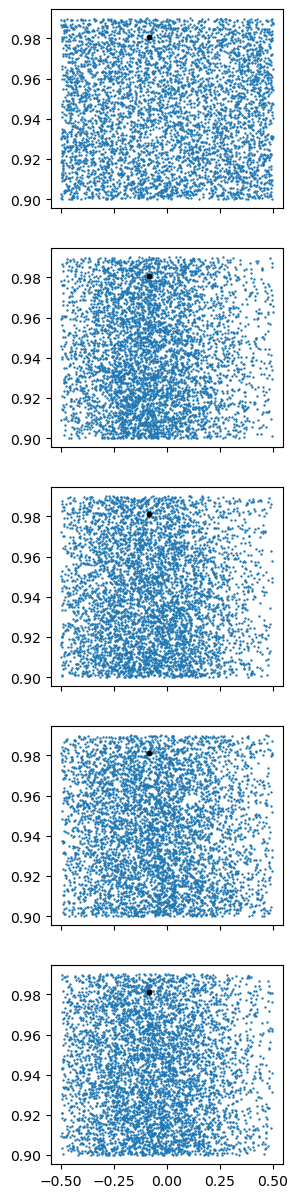

In [ ]:
sim_store = manager.store
log_plot = False


x = 0
y = 1
rounds = range(num_rounds)
# rounds = [0, num_rounds-1]

_, ax = plt.subplots(len(rounds), 1, sharex=True, figsize=(3, 3 * len(rounds)))

for r, i in zip(rounds, range(len(rounds))):
    theta, _ = sim_store.theta[r], sim_store.x[r]
    if log_plot:
        ax[i].scatter(torch.log(theta[:, :, x]), torch.log(theta[:, :, y]), s=0.5)#, alpha=(r+1) / len(rounds))
        ax[i].scatter(torch.log(theta_0[:, x]), torch.log(theta_0[:, y]), s=10, color="black")
        # ax[r].set_xlim((-4, 2))
        # ax[r].set_ylim((-3.1, -0.5))
    else:
        ax[i].scatter(theta[:, :, x], theta[:, :, y], s=0.5)#, alpha=(r+1) / len(rounds))
        ax[i].scatter(theta_0[:, x], theta_0[:, y], s=10, color="black")
        # ax[r].set_xlim(0, 2.5)
        # ax[r].set_ylim(0, 0.5)
    msg = f"True: {theta_0} - Mean: {theta.mean(dim=0)} - Std: {theta.std(dim=0)}"
    print(msg)
    logger.info(msg)
plt.savefig("output/sv_posterior.png")

In [ ]:
# theta, x = task.simulate_dataset((10000,))
# import corner

# # for i in range(theta.shape[0]):
# samples = theta.numpy()
# fig = corner.corner(samples, bins=40, levels=[0.5], labels=['mu', 'phi', 'sigma', 'm'],
#                     plot_datapoints=False, plot_contours=True, smooth=1)
# sim_store.theta[0]
# data = 20*init_dist.sample((5000, 1, 1))
data = torch.cat([task.prior.sample((1000, 2)), 0*init_dist.sample((1000, 2, 4))], dim=0)
mask = task.check_support(data)
# # (data * mask).shape
mask.shape
# data[mask]
# data[mask.all(dim=0)].shape
data[mask.all(dim=-1).all(dim=-1)].shape
# data

torch.Size([0, 2000, 2, 4])